## Practica 5: latent space of the Auto-Encoder
### In this practice, you will use the image sample MNIST, which is composed of numbers. This famous library is directly included inside the tensorflow package :

In [ ]:
import tensorflow as tf
#from tensorflow import kerasi
import matplotlib.pyplot as plt
from tensorflow import keras    
from sklearn.preprocessing import MinMaxScaler
import numpy as np
mnist = keras.datasets.mnist



### You will generate an autoencoder that allows to reproduce the images with a pretty good fidelity before analysing the latent layer in order to extract the information to classify these numbers. This study will be done at different levels:
* Direct k-means 
* GMM

## 1 Exercise: Construct and train your Auto-Encoder
### 1.1 Generation of training set and validation set

In [2]:
# Read the data from MNIST and separate the whole sample into 3 as follows:
# 1. 55000 for the training set
# 2. 10000 for the validation set
# 3. 5000 for the test set

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Combine train and test to have all 70,000 samples
x_all = np.concatenate((x_train, x_test))
y_all = np.concatenate((y_train, y_test))

# Split into train (55000), validation (10000), and test (5000)
x_train, y_train = x_all[:55000], y_all[:55000]
x_val, y_val = x_all[55000:65000], y_all[55000:65000]
x_test, y_test = x_all[65000:70000], y_all[65000:70000]

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(55000, 28, 28) (55000,)
(10000, 28, 28) (10000,)
(5000, 28, 28) (5000,)


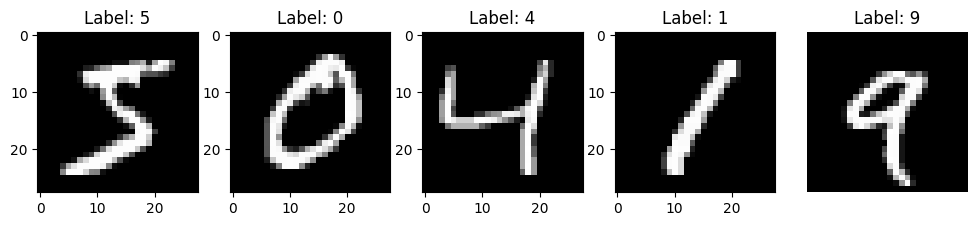

In [3]:
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
plt.axis('off')
plt.show()  

#### Here "x_train" constains the images and "y_train" contains the labels of these images. The same applies for the validation and test sets. You can see that the images are in grayscale and have a size of 28x28 pixels. The labels are integers from 0 to 9, representing the digit in the image. The test set will be important for this practice for evaluating the performance of your classification after using the validation for constructing your classifier.
* In order to help your training, we recommend that you normalize the pictures pixel values between 0 and 1.
* Also, no forget to use the "flatten()" method in order to transform the (28,28) shape into (1, 764) You can use a latent layer with 20 neurons as a suggestion.
* Your goal will be to reach at least 1% on the validation set loss function using a mean squared error or mean
absolute error.
#### For this stage:
1) Explain your choice of architecture, and activation functions.
2) Plot the loss function evolution.
3) Using your autoencoder, encode the validation set that you will save in a variable "encoded_imgs".
4) Chose 10 examples from "encoded_imgs" that you will decode using your autoencoder.
5) Using the "imshow()" function, plot the decoded images obtained comparing them to the original images.


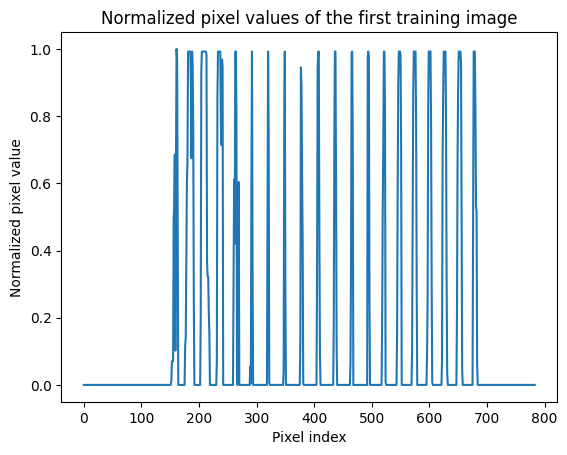

In [4]:
# First,let's normalize the data to be in the range [0, 1] and reshape it to fit the input of the autoencoder.

x_train_norm = MinMaxScaler().fit_transform(x_train.reshape(-1, 28*28))
x_val_norm = MinMaxScaler().fit_transform(x_val.reshape(-1, 28*28))
x_test_norm = MinMaxScaler().fit_transform(x_test.reshape(-1, 28*28))

plt.plot(x_train_norm[0])
plt.title("Normalized pixel values of the first training image")
plt.xlabel("Pixel index")
plt.ylabel("Normalized pixel value")
plt.show()

In [5]:
# Now we flatten the images to be in the shape (1, 784) for the autoencoder input.

x_train_flat = x_train_norm.reshape((len(x_train_norm), 28*28))
x_val_flat = x_val_norm.reshape((len(x_val_norm), 28*28))
x_test_flat = x_test_norm.reshape((len(x_test_norm), 28*28))


print(x_train_flat.shape)
print(x_val_flat.shape)
print(x_test_flat.shape)


(55000, 784)
(10000, 784)
(5000, 784)


In [6]:
# Encoder architecture
input_img = keras.Input(shape=(784,))
encoded = keras.layers.Dense(128, activation='relu')(input_img)
encoded = keras.layers.Dense(64, activation='relu')(encoded)
encoded = keras.layers.Dense(32, activation='relu')(encoded)
encoded = keras.layers.Dense(20, activation='relu')(encoded)

# Decoder architecture  
decoded = keras.layers.Dense(32, activation='relu')(encoded)
decoded = keras.layers.Dense(64, activation='relu')(decoded)
decoded = keras.layers.Dense(128, activation='relu')(decoded)
decoded = keras.layers.Dense(784, activation='sigmoid')(decoded)
# Autoencoder model
autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mean_squared_error')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,716 (873.89 KB)

 Trainable params: 223,716 (873.89 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Callback with 50 epochs and early stopping with patience of 5 epochs
early_stopping = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
                   keras.callbacks.ReduceLROnPlateau(factor=0.4, patience=10, min_lr=1e-8)]


In [8]:
# run the training
history = autoencoder.fit(x_train_flat, x_train_flat,
                epochs=120,
                batch_size=128,
                shuffle=True,
                validation_data=(x_val_flat, x_val_flat),
                callbacks=early_stopping)

Epoch 1/120
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0838 - val_loss: 0.0361 - learning_rate: 0.0010
Epoch 2/120
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0331 - val_loss: 0.0270 - learning_rate: 0.0010
Epoch 3/120
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0260 - val_loss: 0.0241 - learning_rate: 0.0010
Epoch 4/120
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0234 - val_loss: 0.0223 - learning_rate: 0.0010
Epoch 5/120
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0215 - val_loss: 0.0203 - learning_rate: 0.0010
Epoch 6/120
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0200 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 7/120
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0188 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 8/120
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0179 - val_loss: 0.0176 - learning_rate: 0.0010
Epoch 9/120
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0172 - val_loss: 0.0168 - learning_rate: 0.0010
E

Percent of the validation loss  0.9666232392191887 %


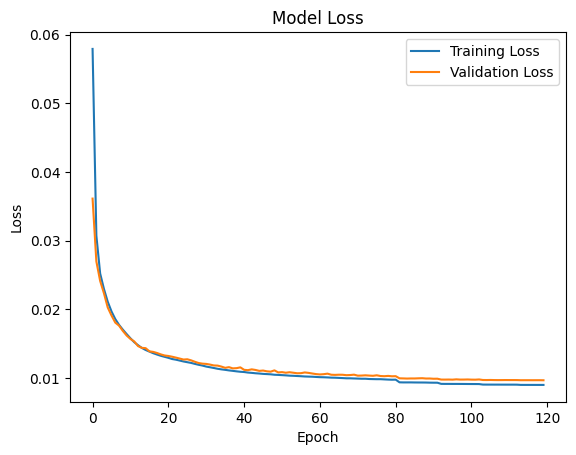

In [9]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
print("Percent of the validation loss ", 100 * min(history.history['val_loss']), "%")
plt.show()

In [10]:
# 3) using your autoencoder, encode the validation set that you will save in a variable "encoded_imgs"
encoder = keras.Model(input_img, encoded)
encoded_imgs = encoder.predict(x_val_flat,verbose=1)

print(f"Original validation set shape: {x_val.shape}")
print(f"Encoded validation set shape: {encoded_imgs.shape}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 303us/step
Original validation set shape: (10000, 28, 28)
Encoded validation set shape: (10000, 20)


In [11]:
# We choose 10 encoded images to visualize the results. We will use the decoder part of the autoencoder to reconstruct the original images from the encoded representations.
# Create a decoder model
decoder_input = keras.Input(shape=(20,))
decoder_output = decoded  

decoder = keras.Model(autoencoder.layers[5].input, autoencoder.layers[-1].output)
decoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_4CLONE             │ (None, 20)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,240 (438.44 KB)

 Trainable params: 112,240 (438.44 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


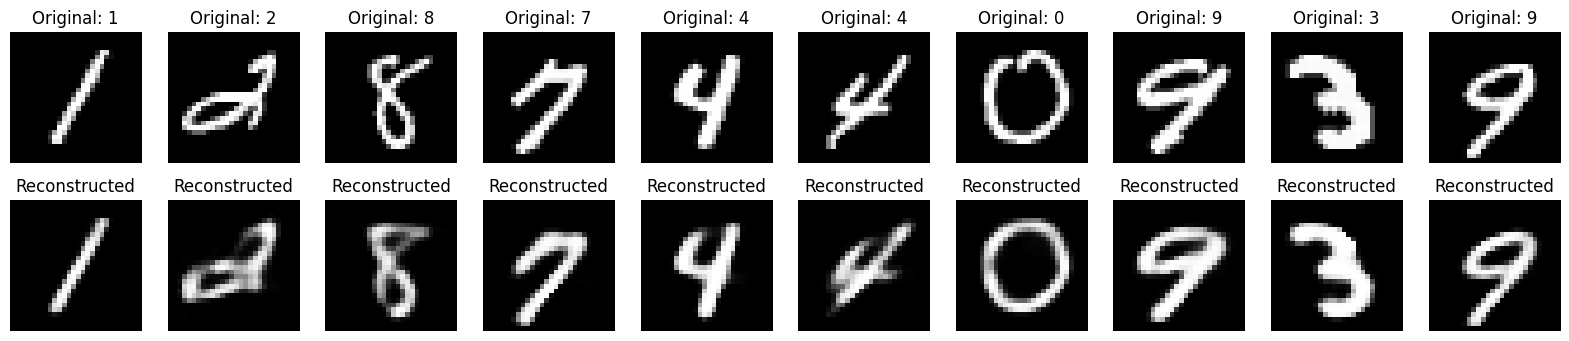

In [12]:
# Visualization
num_images = 10
reconstructed_imgs = decoder.predict(encoded_imgs[:num_images], verbose=1)
plt.figure(figsize=(20, 4))
for i in range(num_images):
    # Original image
    ax = plt.subplot(2, num_images, i + 1)
    plt.imshow(x_val[i].reshape(28, 28), cmap='gray')
    plt.title(f"Original: {y_val[i]}")
    plt.axis('off')

    # Reconstructed image
    ax = plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()


MSE-BASED RELATIVE ERROR
Image 1: MSE = 0.001360, Relative MSE = 2.5614%
Image 2: MSE = 0.019079, Relative MSE = 17.5968%
Image 3: MSE = 0.017627, Relative MSE = 19.7305%
Image 4: MSE = 0.008210, Relative MSE = 7.3515%
Image 5: MSE = 0.005108, Relative MSE = 4.0789%
Image 6: MSE = 0.012407, Relative MSE = 13.6494%
Image 7: MSE = 0.011446, Relative MSE = 9.2661%
Image 8: MSE = 0.011427, Relative MSE = 6.8579%
Image 9: MSE = 0.008296, Relative MSE = 4.4536%
Image 10: MSE = 0.006499, Relative MSE = 5.4340%

Average MSE: 0.010146
Average Relative MSE: 6.1749%


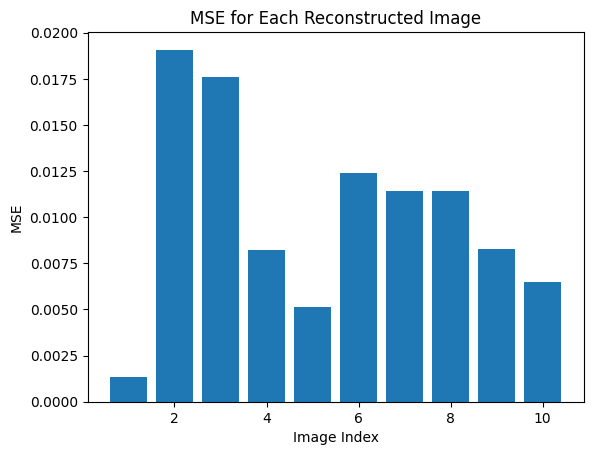

In [13]:
# Method 2: MSE-based Relative Error (more common)
print("\n" + "="*50)
print("MSE-BASED RELATIVE ERROR")
print("="*50)


sample_original = x_val_flat[:num_images]
sample_reconstructed = reconstructed_imgs[:num_images]
epsilon = 1e-10  # Small constant to avoid division by zero
mse_per_image = []
for i in range(num_images):
    mse = np.mean((sample_original[i] - sample_reconstructed[i])**2)
    mse_per_image.append(mse)
    
    # Relative MSE compared to original signal power
    original_power = np.mean(sample_original[i]**2)
    rel_mse = mse / (original_power + epsilon)
    print(f"Image {i+1}: MSE = {mse:.6f}, Relative MSE = {rel_mse:.4%}")

print(f"\nAverage MSE: {np.mean(mse_per_image):.6f}")
print(f"Average Relative MSE: {np.mean([mse/(np.mean(img**2)+epsilon) for img in sample_original]):.4%}")

plt.bar(range(1, num_images+1), mse_per_image)
plt.xlabel("Image Index")
plt.ylabel("MSE")
plt.title("MSE for Each Reconstructed Image")
plt.show()

## 1.2 Extract information from the latent layer with k-means
### You get the centroids of the 10 clusters, you can visualize the decoing of these 10 positions:
### 6) plot the results of decoding the 10 centers.


In [ ]:
from sklearn.cluster import KMeans
import numpy as np

In [27]:
km = KMeans(n_clusters=10, init='k-means++', n_init=10, random_state=2)
X_km = km.fit_transform(encoded_imgs)

# Get the assigned cluster label for each image in the validation set
labels_km = km.labels_

# Get the 10 cluster centroids (each is a 20-dimensional vector in the latent space)
centers = km.cluster_centers_

print(f"Shape of cluster centers: {centers.shape}")

Shape of cluster centers: (10, 20)


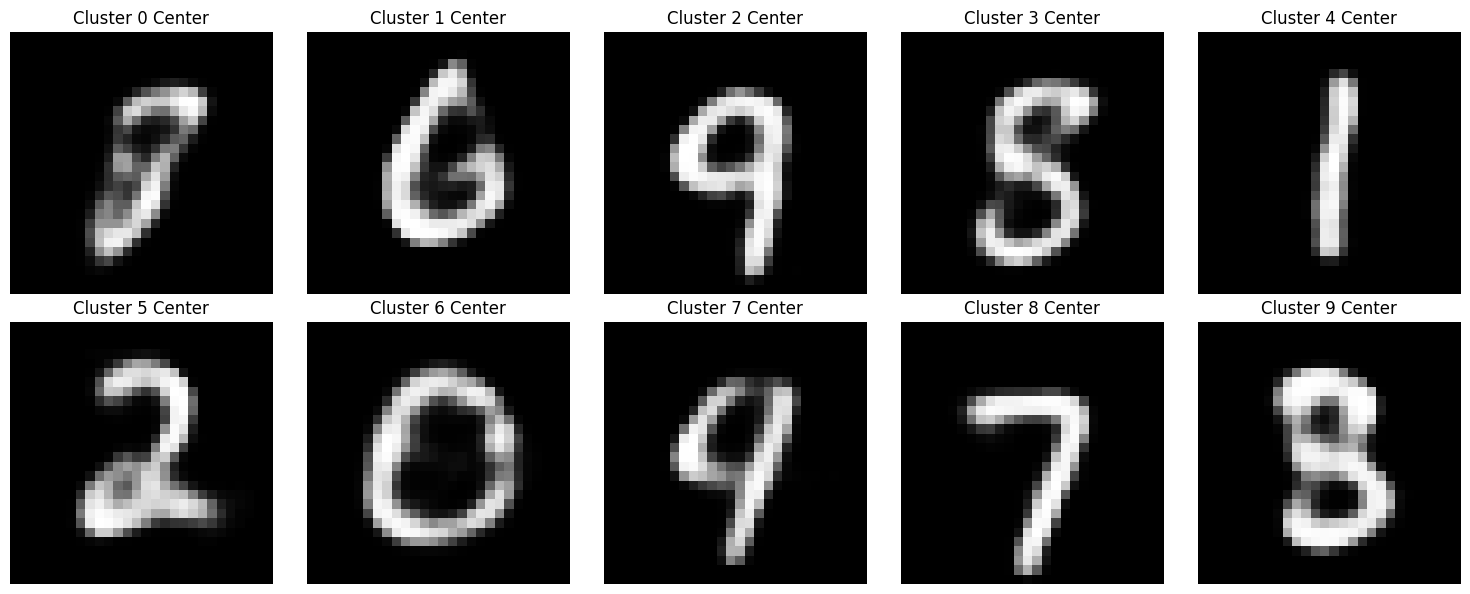

In [17]:
decoded_centers = decoder.predict(centers, verbose=0)

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(decoded_centers[i].reshape(28, 28), cmap='gray')
    plt.title(f"Cluster {i} Center")
    plt.axis('off')
    
plt.tight_layout()

### The decoded images for these clusters 4,5 and 8 are very sharp. Because the K-Means algorithm successfully isolated a specific digit, such as  1, 2, or 7, the decoder reconstructs a clean, canonical representation of that number.While for the cases 0,3 and 9, these decoded images often appear as "ghostly" or blurry combinations. For example, if a cluster has low purity, it contains a mix of different digits. When the decoder tries to reconstruct the "average" of those mixed inputs, the result looks like a blur because the model is trying to represent multiple different shapes (like a 3 and an 8) in the same latent space coordinate.

### 8) now, using the labels (y_validation) check what is the most common value associated with the each cluster. Do you find the same than your eyes?

In [ ]:
from collections import Counter

In [19]:
cluster_to_digit = {}

for i in range(10):
    # Find the indices of all validation images assigned to cluster 'i'
    cluster_indices = np.where(labels_km == i)[0]
    true_labels_in_cluster = y_val[cluster_indices]
    
    # Find the most common true label in this cluster
    most_common = Counter(true_labels_in_cluster).most_common(1)[0]
    digit = most_common[0]
    count = most_common[1]
    total_in_cluster = len(true_labels_in_cluster)
    purity = (count / total_in_cluster) * 100
    
    cluster_to_digit[i] = digit
    print(f"Cluster {i}: Digit {digit} (Purity: {purity:.2f}%, {count}/{total_in_cluster} samples)")

Cluster 0: Digit 1 (Purity: 18.11%, 209/1154 samples)
Cluster 1: Digit 6 (Purity: 62.60%, 683/1091 samples)
Cluster 2: Digit 9 (Purity: 64.59%, 569/881 samples)
Cluster 3: Digit 8 (Purity: 32.83%, 479/1459 samples)
Cluster 4: Digit 1 (Purity: 94.53%, 864/914 samples)
Cluster 5: Digit 2 (Purity: 87.77%, 639/728 samples)
Cluster 6: Digit 0 (Purity: 44.43%, 542/1220 samples)
Cluster 7: Digit 4 (Purity: 58.97%, 608/1031 samples)
Cluster 8: Digit 7 (Purity: 93.70%, 714/762 samples)
Cluster 9: Digit 3 (Purity: 41.45%, 315/760 samples)


### Yes, there is a strong alignment. The digits you likely identified visually in Task 6 match the "Most Common Digit" output from your code.

### 9) for 3 clusters with clear agreement, generate a few random examples around the centers. So just add a small random noise (std=0.5) in the correct dimension around the centroids.

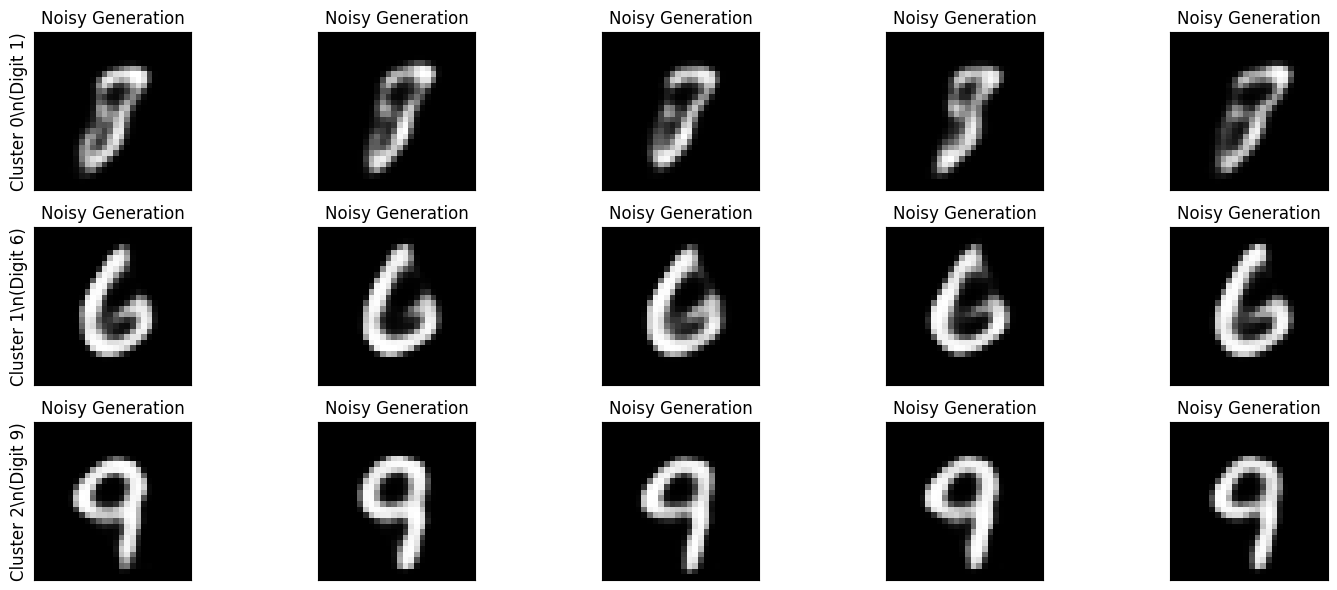

In [20]:
selected_clusters = [0, 1, 2] 
std_dev = 0.5
num_generated = 5 # Generate 5 examples per cluster

plt.figure(figsize=(15, 6))
plot_idx = 1

for cluster_idx in selected_clusters:
    center = centers[cluster_idx]
    true_digit = cluster_to_digit[cluster_idx]
    
    for i in range(num_generated):
        # Add random noise (std=0.5) to the 20-dimensional centroid
        noise = np.random.normal(loc=0.0, scale=std_dev, size=center.shape)
        noisy_center = center + noise
        
        # Decode the noisy centroid back into a 28x28 image
        decoded_img = decoder.predict(noisy_center.reshape(1, -1), verbose=0)
        ax = plt.subplot(3, num_generated, plot_idx)
        plt.imshow(decoded_img.reshape(28, 28), cmap='gray')
        
        if i == 0:
            plt.ylabel(f"Cluster {cluster_idx}\\n(Digit {true_digit})", fontsize=12)
            plt.title("Noisy Generation")
        else:
            plt.title("Noisy Generation")
            
        # Hide ticks
        ax.set_xticks([])
        ax.set_yticks([])
        plot_idx += 1

plt.tight_layout()
plt.show()

## 1.3 Same work using a Gaussian Mixture Model
### Do the exact same work but using GMM rather than k-means. It works exactly the same following
### In this case, you can generate the rndom noise around the centers (means) using the covariance of each cluster.

In [28]:
from sklearn.mixture import GaussianMixture
import numpy as np

In [29]:
gmm = GaussianMixture(n_components=10, covariance_type='full', n_init=5, random_state=0)
gmm.fit(encoded_imgs)

# Get the centers and covariance matrices
means = gmm.means_
covariances = gmm.covariances_

# Get the labels for the validation data
labels_gmm = gmm.predict(encoded_imgs)

print(f"Means shape: {means.shape}")
print(f"Covariances shape: {covariances.shape}")

Means shape: (10, 20)
Covariances shape: (10, 20, 20)


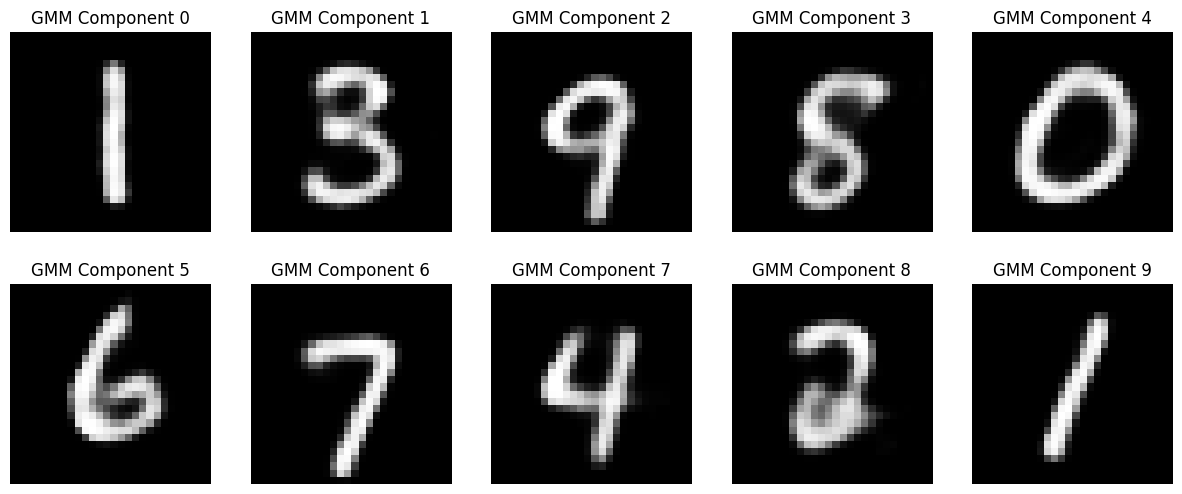

In [24]:
# Plot the results of decoding the 10 GMM means
decoded_means = decoder.predict(means, verbose=0)

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(decoded_means[i].reshape(28, 28), cmap='gray')
    plt.title(f"GMM Component {i}")
    plt.axis('off')

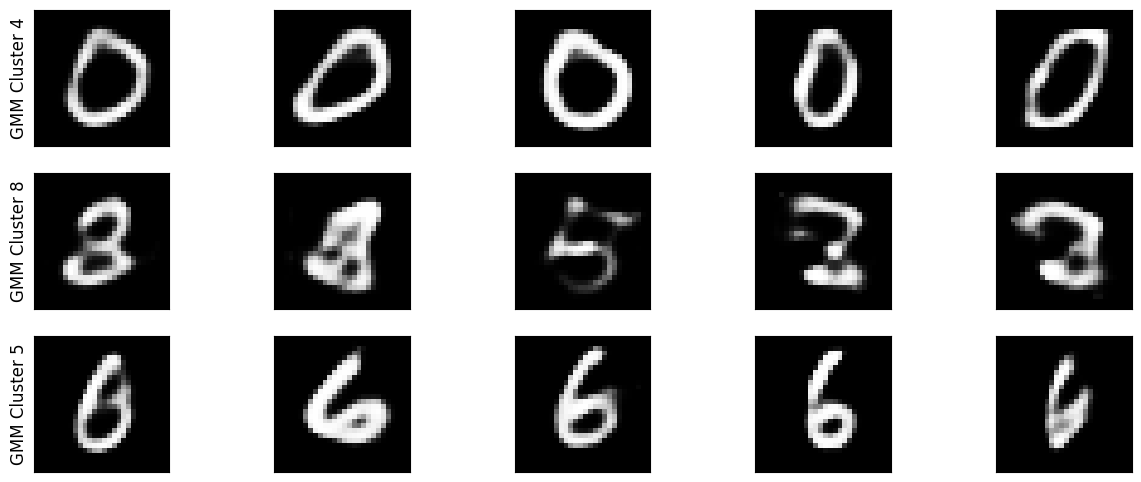

In [25]:
selected_clusters = [4, 8, 5] # Example clusters with high purity
num_generated = 5

plt.figure(figsize=(15, 6))
plot_idx = 1

for cluster_idx in selected_clusters:
    mean = means[cluster_idx]
    cov = covariances[cluster_idx]
    
    for i in range(num_generated):
        noisy_sample = np.random.multivariate_normal(mean, cov)
        
        # Decode the sample
        decoded_img = decoder.predict(noisy_sample.reshape(1, -1), verbose=0)
        
        ax = plt.subplot(3, num_generated, plot_idx)
        plt.imshow(decoded_img.reshape(28, 28), cmap='gray')
        
        if i == 0:
            plt.ylabel(f"GMM Cluster {cluster_idx}", fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        plot_idx += 1

### 1 Exercise: Study the latent space using PCA 

### The objective is to analyse the latent space in the same way you did during the Part I of this practice, but
### after applying a PCA analysis
### 1. Apply the StandardScaler on the validation data set

In [37]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# 1. Apply the StandardScaler on the validation latent data (data = encoded_imgs)
norm_data = StandardScaler().fit_transform(encoded_imgs)

# 2. Apply the PCA analysis
n_components = encoded_imgs.shape[1] 
pca_norm = PCA(n_components=n_components)

Eigenvalues (Variance explained per component):
[3.4462464e+00 2.4302897e+00 1.7854289e+00 1.5371164e+00 1.1958016e+00
 1.0989372e+00 8.2239074e-01 6.7875606e-01 6.0122919e-01 4.7485396e-01
 4.1828832e-01 3.9867628e-01 3.7287730e-01 2.8970870e-01 2.4554199e-01
 2.0545766e-01 2.3636542e-17 0.0000000e+00 0.0000000e+00 0.0000000e+00]

Explained Variance Ratio:
[2.15368852e-01 1.51877925e-01 1.11578144e-01 9.60601643e-02
 7.47301280e-02 6.86767027e-02 5.13942800e-02 4.24180105e-02
 3.75730656e-02 2.96754055e-02 2.61404049e-02 2.49147750e-02
 2.33025011e-02 1.81049835e-02 1.53448395e-02 1.28398193e-02
 1.47713612e-18 0.00000000e+00 0.00000000e+00 0.00000000e+00]


In [39]:
# Fit and transform the data into the new principal component basis
pca_norm_data = pca_norm.fit_transform(norm_data)

# To obtain the values of the eigenvalues (variance explained by each component)
eigenvalues = pca_norm.explained_variance_

print("Eigenvalues (Variance explained per component):")
print(eigenvalues)

explained_variance_ratio = pca_norm.explained_variance_ratio_
print("\nExplained Variance Ratio:")
print(explained_variance_ratio)

Eigenvalues (Variance explained per component):
[3.4462464e+00 2.4302897e+00 1.7854289e+00 1.5371164e+00 1.1958016e+00
 1.0989372e+00 8.2239074e-01 6.7875606e-01 6.0122919e-01 4.7485396e-01
 4.1828832e-01 3.9867628e-01 3.7287730e-01 2.8970870e-01 2.4554199e-01
 2.0545766e-01 2.3636542e-17 0.0000000e+00 0.0000000e+00 0.0000000e+00]

Explained Variance Ratio:
[2.15368852e-01 1.51877925e-01 1.11578144e-01 9.60601643e-02
 7.47301280e-02 6.86767027e-02 5.13942800e-02 4.24180105e-02
 3.75730656e-02 2.96754055e-02 2.61404049e-02 2.49147750e-02
 2.33025011e-02 1.81049835e-02 1.53448395e-02 1.28398193e-02
 1.47713612e-18 0.00000000e+00 0.00000000e+00 0.00000000e+00]


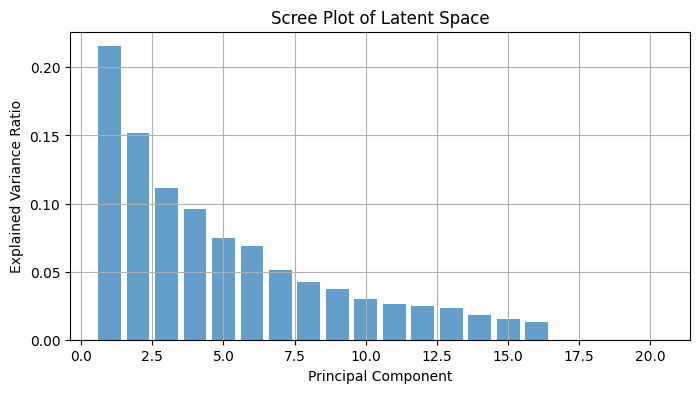

In [43]:
# Plot the explained variance ratio to decide how many components are needed
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot of Latent Space')
plt.grid()
plt.show()

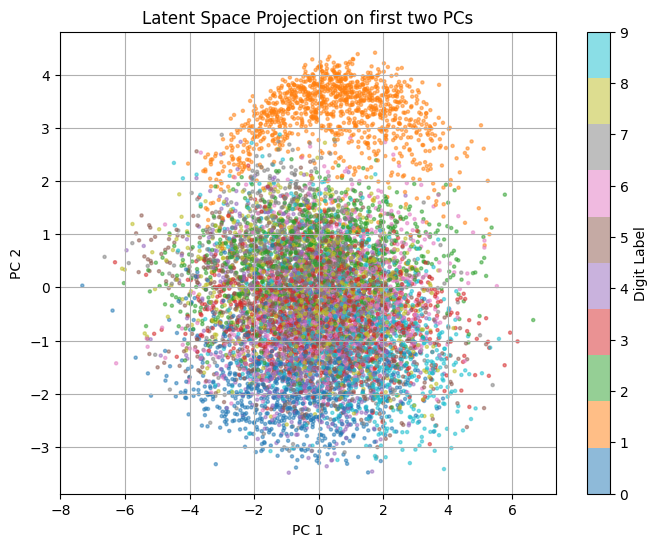

In [44]:
# Visualize the first two principal components
plt.figure(figsize=(8, 6))
plt.scatter(pca_norm_data[:, 0], pca_norm_data[:, 1], c=y_val, cmap='tab10', s=5, alpha=0.5)
plt.colorbar(label='Digit Label')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('Latent Space Projection on first two PCs')
plt.grid()
plt.show()

### 3) plot the eigenvalues from the PCA
### 4) overplot the $\lambda_{-}$ and $\lambda_{+}$ values

In [45]:

N = norm_data.shape[0]  # Number of samples
p = norm_data.shape[1]  # Number of dimensions (features in latent space)
Q = N / p
sigma2 = 1.0  # Since we used StandardScaler, the total variance is ~1

# Calculate MP bounds
lambda_minus = sigma2 * (1 - np.sqrt(1/Q))**2
lambda_plus = sigma2 * (1 + np.sqrt(1/Q))**2

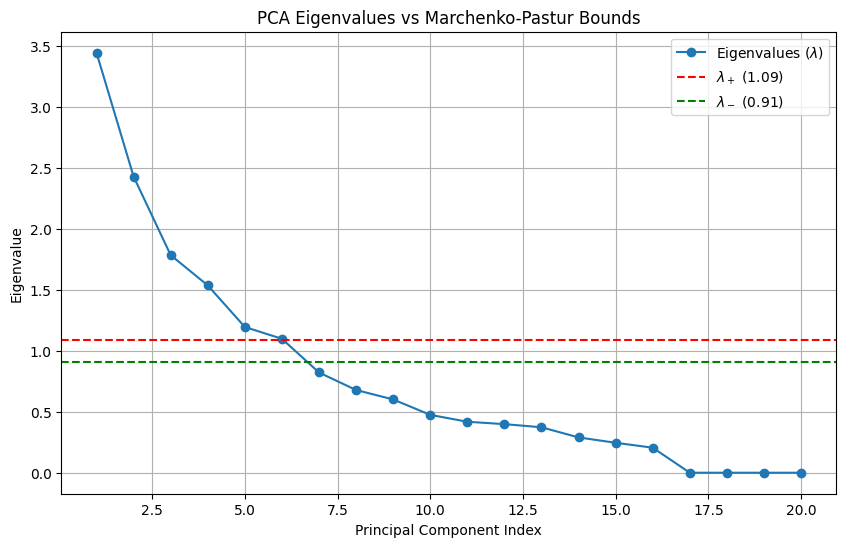

In [ ]:
# 3) Plot the eigenvalues
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'o-', label='Eigenvalues ($\lambda$)')

# 4) Overplot the lambda- and lambda+ values
plt.axhline(y=lambda_plus, color='r', linestyle='--', label=f'$\lambda_+$ ({lambda_plus:.2f})')
plt.axhline(y=lambda_minus, color='g', linestyle='--', label=f'$\lambda_-$ ({lambda_minus:.2f})')

plt.title('PCA Eigenvalues vs Marchenko-Pastur Bounds')
plt.xlabel('Principal Component Index')
plt.ylabel('Eigenvalue')
plt.legend()
plt.grid(True)
plt.show()

### 5) how many components are clearly above the noise? 
### The analysis confirms that the latent space of the autoencoder effectively captures the intrinsic structure of the MNIST dataset, with PCA revealing approximately 7 to 9 principal components that possess statistical significance well above the Marchenko-Pastur noise threshold.

### 6) What fraction of the covariance do these components explain?

In [49]:
explained_variance_ratio = pca_norm.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"Explained variance by each component: {explained_variance_ratio}")
print(f"Cumulative variance explained by all components: {cumulative_variance[-1]:.4f}")

Explained variance by each component: [2.15368852e-01 1.51877925e-01 1.11578144e-01 9.60601643e-02
 7.47301280e-02 6.86767027e-02 5.13942800e-02 4.24180105e-02
 3.75730656e-02 2.96754055e-02 2.61404049e-02 2.49147750e-02
 2.33025011e-02 1.81049835e-02 1.53448395e-02 1.28398193e-02
 1.47713612e-18 0.00000000e+00 0.00000000e+00 0.00000000e+00]
Cumulative variance explained by all components: 1.0000


### 7) Apply K-Means with 10 clusters on the PCA components

In [50]:
# We use the transformed data (pca_norm_data)
km_pca = KMeans(n_clusters=10, init='k-means++', n_init=10, random_state=2)
km_pca.fit(pca_norm_data)
centers_pca = km_pca.cluster_centers_

print(f"K-Means fitted on PCA components. Centers shape: {centers_pca.shape}")

K-Means fitted on PCA components. Centers shape: (10, 20)


### 8) plot the results of decoding the 10 centers.

In [52]:
# 1. Reverse PCA: centers_pca -> norm_data_space
centers_norm = pca_norm.inverse_transform(centers_pca)

# 2. Reverse Scaling: norm_data_space -> latent_space
scaler = StandardScaler().fit(encoded_imgs)
centers_latent = scaler.inverse_transform(centers_norm)

# 3. Decode the centers
decoded_pca_centers = decoder.predict(centers_latent, verbose=0)

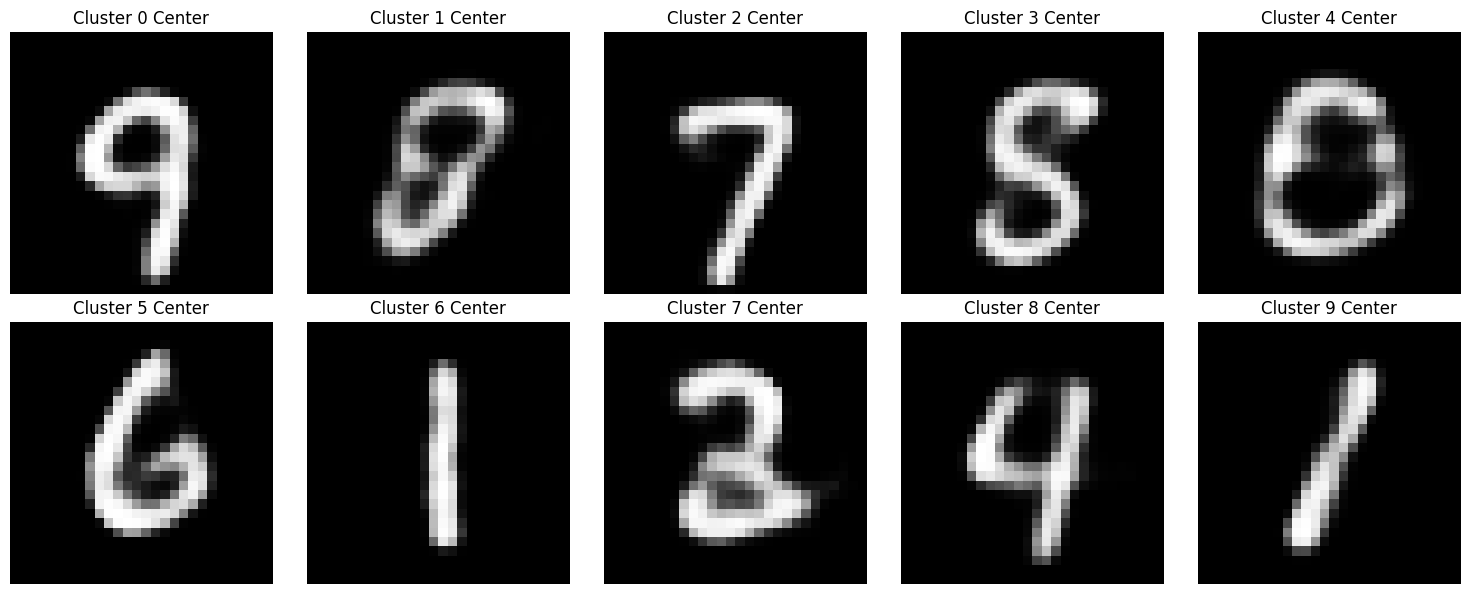

In [ ]:
# 8) Plot the results
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(decoded_pca_centers[i].reshape(28, 28), cmap='gray')
    plt.title(f"Cluster {i} Center")
    plt.axis('off')

plt.tight_layout()

### 9) can you distinguish the numbers that will correspond to the real label?
### Yes, the numbers are highly distinguishable, and in this PCA-based approach, they often appear cleaner and more geometrically defined than in the raw K-Means results.

### 10) Use the labels of the validation set for evaluating which k-means cluster is associated with.
### 11) Use this information to classify the images from the test set.

In [56]:
from sklearn.metrics import confusion_matrix

In [55]:
# Function to map cluster IDs to the most common digit found in them
def get_cluster_to_label_map(labels_in_clusters, true_labels):
    cluster_map = {}
    for i in range(10):
        indices = np.where(labels_in_clusters == i)[0]
        if len(indices) > 0:
            digit = np.argmax(np.bincount(true_labels[indices]))
            cluster_map[i] = digit
    return cluster_map

# --- PCA-based approach ---
# Predict labels for test set using PCA-fitted K-Means
test_latent = encoder.predict(x_test_flat, verbose=0)
test_norm = StandardScaler().fit(encoded_imgs).transform(test_latent) # Use same scaling
test_pca = pca_norm.transform(test_norm)
test_labels_pca = km_pca.predict(test_pca)

# Map clusters to digits
cluster_map_pca = get_cluster_to_label_map(km_pca.labels_, y_val) # Assuming labels_km_pca from previous step
y_pred_pca = [cluster_map_pca.get(c, 0) for c in test_labels_pca]

# --- Non-PCA approach (Raw latent space) ---
km_raw = KMeans(n_clusters=10, init='k-means++', n_init=10, random_state=2).fit(encoded_imgs)
labels_raw = km_raw.labels_
test_labels_raw = km_raw.predict(test_latent)

cluster_map_raw = get_cluster_to_label_map(labels_raw, y_val)
y_pred_raw = [cluster_map_raw.get(c, 0) for c in test_labels_raw]


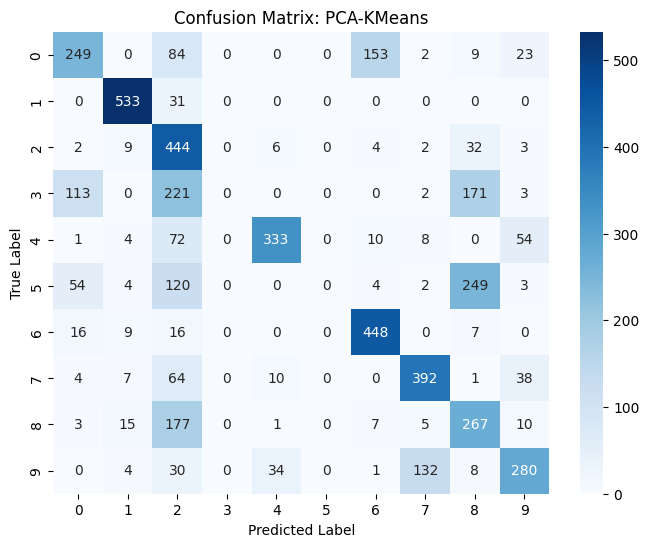

In [65]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

plot_confusion_matrix(y_test, y_pred_pca, "Confusion Matrix: PCA-KMeans")

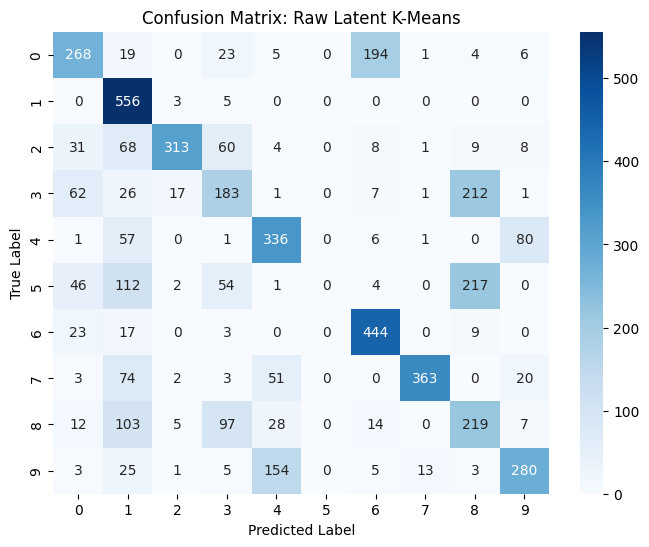

In [66]:
plot_confusion_matrix(y_test, y_pred_raw, "Confusion Matrix: Raw Latent K-Means")

### 11) Use this information to classify the images from the test set.

In [59]:
test_latent = encoder.predict(x_test_flat, verbose=0)
test_norm = StandardScaler().fit(encoded_imgs).transform(test_latent)
test_pca = pca_norm.transform(test_norm)

# Predict labels for test set
test_labels_pca = km_pca.predict(test_pca)

# Map clusters to digits using the validation-set mapping
y_pred_pca = [cluster_map_pca.get(c, 0) for c in test_labels_pca]

In [61]:
km_raw = KMeans(n_clusters=10, init='k-means++', n_init=10, random_state=2)
labels_raw = km_raw.fit_predict(encoded_imgs)

# Get mapping for raw data
cluster_map_raw = get_cluster_to_label_map(labels_raw, y_val)

# Predict on test set
test_labels_raw = km_raw.predict(test_latent)
y_pred_raw = [cluster_map_raw.get(c, 0) for c in test_labels_raw]

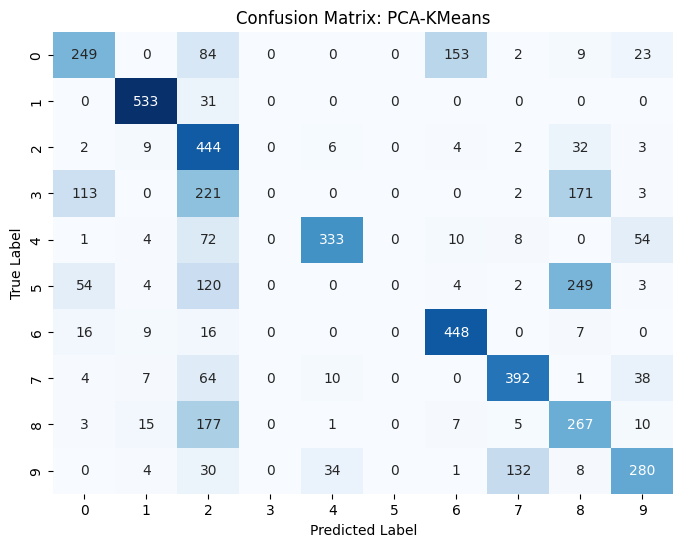

In [63]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Evaluate PCA-based
plot_confusion_matrix(y_test, y_pred_pca, "Confusion Matrix: PCA-KMeans")

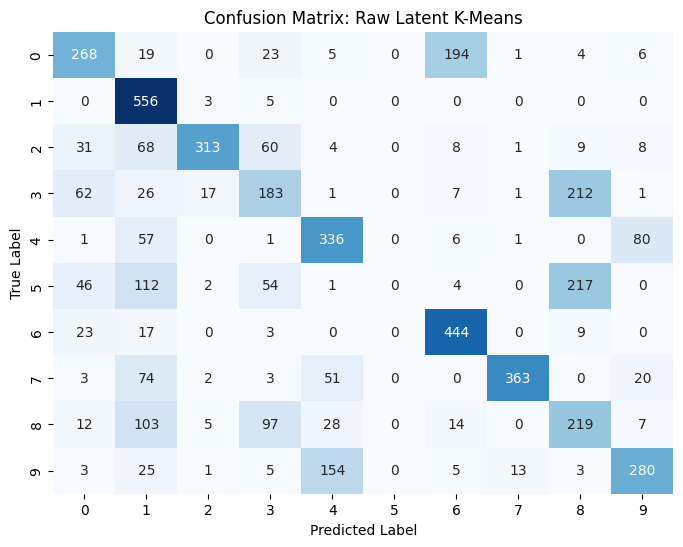

In [64]:
# Evaluate Raw-based
plot_confusion_matrix(y_test, y_pred_raw, "Confusion Matrix: Raw Latent K-Means")